# GraphCL + GAT for Human non-TATA Promoter Classification

**Purpose:** This notebook loads the Human non-TATA promoter dataset, converts DNA sequences into k-mer graphs, applies GraphCL self-supervised pretraining, then fine-tunes a GAT classifier.

**Main pipeline:**

`DNA sequence → preprocessing → k-mer graph → GraphCL + GAT encoder → classifier → evaluation`

Change only `K` in the configuration cell to test different k-mer sizes such as 5, 6, or 7.

## 1. Install and Import Libraries

In [129]:
# Run this once in Kaggle/Colab if packages are missing
!pip install -q genomic-benchmarks torch-geometric networkx

In [130]:
import os
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
    roc_auc_score
)

from genomic_benchmarks.dataset_getters.pytorch_datasets import get_dataset
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GATConv, global_mean_pool

print("Imports completed")

Imports completed


## 2. Configuration

Use this cell to select the k-mer size. For experiments, run the notebook with `K=5`, then `K=6`, then `K=7`, and compare final Accuracy / F1 / ROC-AUC.

In [131]:
SEED = 42
K = 6             # Try K = 5, 6, 7
BATCH_SIZE = 32
VAL_RATIO = 0.20      # Keep unchanged for fair comparison
HIDDEN_DIM = 256
HEADS = 4

PRETRAIN_EPOCHS = 100
CLASSIFIER_EPOCHS = 100

SSL_LR = 2e-4
CLS_LR = 1e-4
WEIGHT_DECAY = 5e-5
DROPOUT_ENCODER = 0.20
DROPOUT_CLASSIFIER = 0.20

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
print("K-mer size:", K)

Using device: cuda
K-mer size: 6


## 3. Load Dataset

In [132]:
train_data = get_dataset("human_nontata_promoters", split="train")
test_data  = get_dataset("human_nontata_promoters", split="test")

print("Train samples:", len(train_data))
print("Test samples :", len(test_data))
print("Total samples:", len(train_data) + len(test_data))

Train samples: 27097
Test samples : 9034
Total samples: 36131


## 4. Convert Dataset to DataFrame and Split Train/Validation

The official test split is kept unchanged. Only the training split is divided into train and validation using stratified sampling.

In [133]:
def to_df(dataset):
    seqs, labels = [], []
    for seq, label in dataset:
        seqs.append(str(seq).upper())
        labels.append(int(label))
    return pd.DataFrame({"sequence": seqs, "label": labels})

full_train_df = to_df(train_data)
test_df = to_df(test_data)

train_df, val_df = train_test_split(
    full_train_df,
    test_size=VAL_RATIO,
    random_state=SEED,
    stratify=full_train_df["label"]
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))
print("Label distribution in train:")
print(train_df["label"].value_counts(normalize=True))

Train: 21677
Validation: 5420
Test: 9034
Label distribution in train:
label
0    0.544033
1    0.455967
Name: proportion, dtype: float64


## 5. DNA Preprocessing and k-mer Graph Construction

Each DNA sequence is converted into a graph:

- **Node:** one positional k-mer occurrence
- **Edge:** transition between consecutive k-mers in both directions
- **Node features:** one-hot nucleotide encoding + normalized position + GC content + unknown-base fraction

Repeated k-mers are **not collapsed**; each occurrence becomes a separate node.

In [134]:
def sequence_to_kmers(sequence, k):
    sequence = str(sequence).upper()
    kmers = [sequence[i:i+k] for i in range(max(len(sequence) - k + 1, 0))]
    if len(kmers) == 0:
        kmers = [sequence]
    return kmers


def kmer_to_vector(kmer, position=0, seq_len=1, k=6):
    mapping = {"A": 0, "T": 1, "G": 2, "C": 3}

    kmer = str(kmer).upper()
    if len(kmer) < k:
        kmer = kmer + ("N" * (k - len(kmer)))
    else:
        kmer = kmer[:k]

    vec = []
    unknown_count = 0

    for base in kmer:
        one_hot = [0.0, 0.0, 0.0, 0.0]
        if base in mapping:
            one_hot[mapping[base]] = 1.0
        else:
            unknown_count += 1
        vec.extend(one_hot)

    normalized_position = position / max(seq_len - 1, 1)
    gc_content = (kmer.count("G") + kmer.count("C")) / k
    unknown_fraction = unknown_count / k

    vec.extend([normalized_position, gc_content, unknown_fraction])
    return vec


def build_kmer_graph(sequence, label, k=6):
    kmers = sequence_to_kmers(sequence, k)
    seq_len = len(kmers)

    x = [
        kmer_to_vector(kmer, position=i, seq_len=seq_len, k=k)
        for i, kmer in enumerate(kmers)
    ]
    x = torch.tensor(x, dtype=torch.float)

    edges = []
    for i in range(seq_len - 1):
        edges.append([i, i + 1])
        edges.append([i + 1, i])

    if len(edges) == 0:
        edge_index = torch.empty((2, 0), dtype=torch.long)
    else:
        edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()

    y = torch.tensor([int(label)], dtype=torch.long)
    return Data(x=x, edge_index=edge_index, y=y)


def create_graph_dataset(df, k=6):
    graphs = []
    for _, row in df.iterrows():
        graphs.append(build_kmer_graph(row["sequence"], row["label"], k=k))
    return graphs

print("Graph functions ready")

Graph functions ready


## 6. Create Graph Dataset and DataLoaders

In [135]:
train_graphs = create_graph_dataset(train_df, k=K)
val_graphs   = create_graph_dataset(val_df, k=K)
test_graphs  = create_graph_dataset(test_df, k=K)

IN_DIM = train_graphs[0].x.shape[1]

train_loader = DataLoader(train_graphs, batch_size=BATCH_SIZE, shuffle=True)
# Drop last only for GraphCL, so contrastive batches are stable.
train_ssl_loader = DataLoader(train_graphs, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
val_loader = DataLoader(val_graphs, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_graphs, batch_size=BATCH_SIZE, shuffle=False)

print("Train graphs:", len(train_graphs))
print("Val graphs  :", len(val_graphs))
print("Test graphs :", len(test_graphs))
print("IN_DIM      :", IN_DIM)
print("Example graph:", train_graphs[0])
print("Example x shape:", train_graphs[0].x.shape)

Train graphs: 21677
Val graphs  : 5420
Test graphs : 9034
IN_DIM      : 27
Example graph: Data(x=[246, 27], edge_index=[2, 490], y=[1])
Example x shape: torch.Size([246, 27])


## 7. GraphCL Augmentations and Training Utilities

In [136]:
def drop_edges(data, p=0.15):
    data = data.clone()
    edge_index = data.edge_index
    num_edges = edge_index.size(1)

    if num_edges <= 1:
        return data

    mask = torch.rand(num_edges, device=edge_index.device) > p

    if mask.sum() == 0:
        keep_idx = torch.randint(0, num_edges, (1,), device=edge_index.device)
        mask[keep_idx] = True

    data.edge_index = edge_index[:, mask]
    return data


def mask_nodes(data, p=0.15):
    data = data.clone()
    x = data.x.clone()

    mask = torch.rand(x.size(0), device=x.device) > p
    x[~mask] = 0.0

    data.x = x
    return data


def contrastive_loss(z1, z2, temp=0.5):
    z1 = F.normalize(z1, dim=1)
    z2 = F.normalize(z2, dim=1)

    logits_12 = torch.mm(z1, z2.t()) / temp
    logits_21 = torch.mm(z2, z1.t()) / temp

    labels = torch.arange(z1.size(0), device=z1.device)

    loss_12 = F.cross_entropy(logits_12, labels)
    loss_21 = F.cross_entropy(logits_21, labels)

    return (loss_12 + loss_21) / 2


def train_supervised(loader, model, optimizer, device):
    model.train()
    total_loss, total_correct, total_samples = 0.0, 0, 0

    for data in loader:
        data = data.to(device)

        logits = model(data.x, data.edge_index, data.batch)
        loss = F.cross_entropy(logits, data.y)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0)
        optimizer.step()

        batch_size = data.y.size(0)
        total_loss += loss.item() * batch_size
        total_correct += (logits.argmax(dim=1) == data.y).sum().item()
        total_samples += batch_size

    return total_loss / total_samples, total_correct / total_samples


def evaluate(loader, model, device):
    model.eval()
    total_loss, total_correct, total_samples = 0.0, 0, 0
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for data in loader:
            data = data.to(device)

            logits = model(data.x, data.edge_index, data.batch)
            loss = F.cross_entropy(logits, data.y)
            probs = F.softmax(logits, dim=1)
            preds = probs.argmax(dim=1)

            batch_size = data.y.size(0)
            total_loss += loss.item() * batch_size
            total_correct += (preds == data.y).sum().item()
            total_samples += batch_size

            all_preds.extend(preds.cpu().numpy().tolist())
            all_labels.extend(data.y.cpu().numpy().tolist())
            all_probs.extend(probs.cpu().numpy().tolist())

    avg_loss = total_loss / total_samples
    avg_acc = total_correct / total_samples

    return avg_loss, avg_acc, np.array(all_preds), np.array(all_labels), np.array(all_probs)

print("Utility functions ready")

Utility functions ready


## 8. GAT Encoder for GraphCL Pretraining

In [137]:
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATConv, global_mean_pool

class GATEncoder(nn.Module):
    def __init__(self, in_dim, hidden_dim=256, heads=4, dropout=0.2):
        super().__init__()

        self.gat1 = GATConv(in_dim, hidden_dim // heads, heads=heads, dropout=dropout)
        self.gat2 = GATConv(hidden_dim, hidden_dim, heads=1, dropout=dropout)

        self.bn1 = nn.BatchNorm1d(hidden_dim)
        self.bn2 = nn.BatchNorm1d(hidden_dim)

        self.dropout = dropout

    def forward(self, x, edge_index, batch):
        x = self.gat1(x, edge_index)
        x = self.bn1(x)
        x = F.elu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.gat2(x, edge_index)
        x = self.bn2(x)
        x = F.elu(x)

        return global_mean_pool(x, batch)



GATEncoder ready


## 9. GraphCL Pretraining with GAT

In [138]:
gat_encoder = GATEncoder(
    in_dim=IN_DIM,
    hidden_dim=HIDDEN_DIM,
    heads=HEADS,
    dropout=DROPOUT_ENCODER
).to(device)

optimizer_ssl = torch.optim.AdamW(
    gat_encoder.parameters(),
    lr=SSL_LR,
    weight_decay=WEIGHT_DECAY
)

scheduler_ssl = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_ssl,
    mode="min",
    factor=0.5,
    patience=8
)

graphcl_history = {"epoch": [], "loss": []}

def train_graphcl_epoch(loader):
    gat_encoder.train()
    total_loss = 0.0

    for data in loader:
        data = data.to(device)

        g1 = drop_edges(data, p=0.2)
        g2 = mask_nodes(data, p=0.1)

        z1 = gat_encoder(g1.x, g1.edge_index, g1.batch)
        z2 = gat_encoder(g2.x, g2.edge_index, g2.batch)

        loss = contrastive_loss(z1, z2, temp=0.5)

        optimizer_ssl.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(gat_encoder.parameters(), max_norm=2.0)
        optimizer_ssl.step()

        total_loss += loss.item()

    return total_loss / len(loader)

for epoch in range(1, PRETRAIN_EPOCHS + 1):
    loss = train_graphcl_epoch(train_ssl_loader)
    scheduler_ssl.step(loss)

    graphcl_history["epoch"].append(epoch)
    graphcl_history["loss"].append(loss)

    print(f"GAT-GraphCL Epoch {epoch:03d} | Loss: {loss:.4f}")

torch.save(gat_encoder.state_dict(), f"gat_graphcl_encoder_k{K}.pt")
print("Saved pretrained GAT encoder")

GAT-GraphCL Epoch 001 | Loss: 2.2476
GAT-GraphCL Epoch 002 | Loss: 1.9612
GAT-GraphCL Epoch 003 | Loss: 1.9100
GAT-GraphCL Epoch 004 | Loss: 1.8788
GAT-GraphCL Epoch 005 | Loss: 1.8576
GAT-GraphCL Epoch 006 | Loss: 1.8443
GAT-GraphCL Epoch 007 | Loss: 1.8311
GAT-GraphCL Epoch 008 | Loss: 1.8174
GAT-GraphCL Epoch 009 | Loss: 1.8065
GAT-GraphCL Epoch 010 | Loss: 1.7979
GAT-GraphCL Epoch 011 | Loss: 1.7916
GAT-GraphCL Epoch 012 | Loss: 1.7891
GAT-GraphCL Epoch 013 | Loss: 1.7867
GAT-GraphCL Epoch 014 | Loss: 1.7846
GAT-GraphCL Epoch 015 | Loss: 1.7839
GAT-GraphCL Epoch 016 | Loss: 1.7829
GAT-GraphCL Epoch 017 | Loss: 1.7816
GAT-GraphCL Epoch 018 | Loss: 1.7804
GAT-GraphCL Epoch 019 | Loss: 1.7799
GAT-GraphCL Epoch 020 | Loss: 1.7783
GAT-GraphCL Epoch 021 | Loss: 1.7785
GAT-GraphCL Epoch 022 | Loss: 1.7780
GAT-GraphCL Epoch 023 | Loss: 1.7779
GAT-GraphCL Epoch 024 | Loss: 1.7769
GAT-GraphCL Epoch 025 | Loss: 1.7767
GAT-GraphCL Epoch 026 | Loss: 1.7760
GAT-GraphCL Epoch 027 | Loss: 1.7765
G

## 10. GAT Classifier Fine-tuning

In [140]:
class GATClassifier(nn.Module):
    def __init__(self, encoder, hidden_dim=256, num_classes=2, dropout=0.2):
        super().__init__()

        self.encoder = encoder

        self.fc = nn.Sequential(
            nn.Linear(hidden_dim, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes)
        )

    def forward(self, x, edge_index, batch):
        emb = self.encoder(x, edge_index, batch)
        return self.fc(emb)

model = GATClassifier(
    encoder=gat_encoder,
    hidden_dim=HIDDEN_DIM,
    num_classes=2,
    dropout=DROPOUT_CLASSIFIER
).to(device)

optimizer_cls = torch.optim.AdamW(
    model.parameters(),
    lr=CLS_LR,
    weight_decay=WEIGHT_DECAY
)

scheduler_cls = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_cls,
    mode="max",
    factor=0.5,
    patience=10
)

best_val_acc = 0.0
best_val_loss = float("inf")
best_state = None

history = {
    "epoch": [],
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": []
}

for epoch in range(1, CLASSIFIER_EPOCHS + 1):
    train_loss, train_acc = train_supervised(train_loader, model, optimizer_cls, device)
    val_loss, val_acc, _, _, _ = evaluate(val_loader, model, device)

    scheduler_cls.step(val_acc)

    history["epoch"].append(epoch)
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_val_loss = val_loss
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    print(
        f"Epoch {epoch:03d} | "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}"
    )

if best_state is not None:
    model.load_state_dict(best_state)

print("Best Validation Accuracy:", best_val_acc)
print("Best Validation Loss:", best_val_loss)

Epoch 001 | Train Loss: 0.4830 | Train Acc: 0.7694 | Val Loss: 0.4376 | Val Acc: 0.7998
Epoch 002 | Train Loss: 0.4309 | Train Acc: 0.7981 | Val Loss: 0.4199 | Val Acc: 0.8085
Epoch 003 | Train Loss: 0.4189 | Train Acc: 0.8043 | Val Loss: 0.4138 | Val Acc: 0.8111
Epoch 004 | Train Loss: 0.4047 | Train Acc: 0.8134 | Val Loss: 0.3826 | Val Acc: 0.8297
Epoch 005 | Train Loss: 0.3974 | Train Acc: 0.8194 | Val Loss: 0.3733 | Val Acc: 0.8375
Epoch 006 | Train Loss: 0.3873 | Train Acc: 0.8239 | Val Loss: 0.3717 | Val Acc: 0.8378
Epoch 007 | Train Loss: 0.3812 | Train Acc: 0.8248 | Val Loss: 0.3606 | Val Acc: 0.8439
Epoch 008 | Train Loss: 0.3773 | Train Acc: 0.8295 | Val Loss: 0.3551 | Val Acc: 0.8424
Epoch 009 | Train Loss: 0.3751 | Train Acc: 0.8282 | Val Loss: 0.3568 | Val Acc: 0.8435
Epoch 010 | Train Loss: 0.3705 | Train Acc: 0.8311 | Val Loss: 0.3642 | Val Acc: 0.8428
Epoch 011 | Train Loss: 0.3669 | Train Acc: 0.8350 | Val Loss: 0.3529 | Val Acc: 0.8458
Epoch 012 | Train Loss: 0.3672 |

## 11. Final Test Evaluation

In [141]:
test_loss, test_acc, test_preds, test_labels, test_probs = evaluate(test_loader, model, device)

print("GraphCL + GAT Test Loss:", test_loss)
print("GraphCL + GAT Test Accuracy:", test_acc)
print("\nClassification Report:")
print(classification_report(test_labels, test_preds, digits=4))

GraphCL + GAT Test Loss: 0.34636667905713914
GraphCL + GAT Test Accuracy: 0.8551029444321452

Classification Report:
              precision    recall  f1-score   support

           0     0.9595    0.7660    0.8519      4915
           1     0.7750    0.9614    0.8582      4119

    accuracy                         0.8551      9034
   macro avg     0.8672    0.8637    0.8550      9034
weighted avg     0.8753    0.8551    0.8548      9034



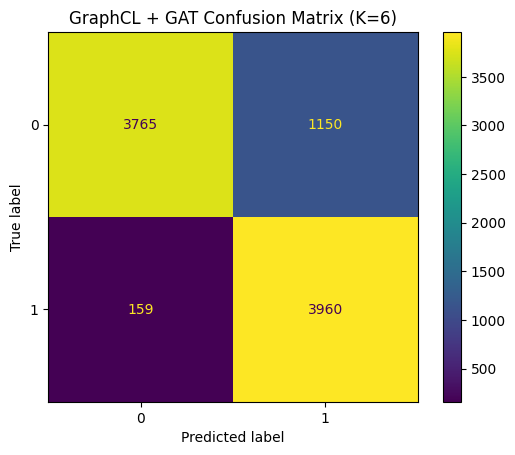

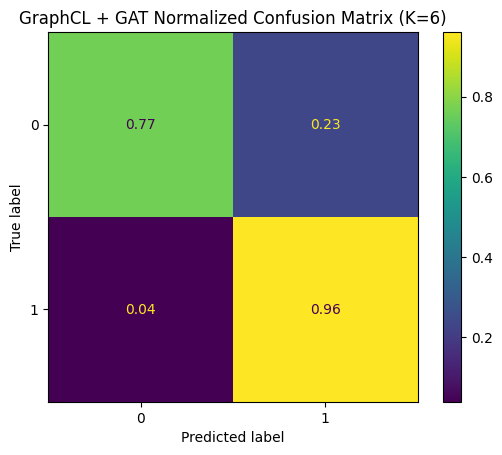

In [142]:
cm = confusion_matrix(test_labels, test_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(values_format="d")
plt.title(f"GraphCL + GAT Confusion Matrix (K={K})")
plt.show()

cm_norm = confusion_matrix(test_labels, test_preds, normalize="true")
disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm)
disp_norm.plot(values_format=".2f")
plt.title(f"GraphCL + GAT Normalized Confusion Matrix (K={K})")
plt.show()

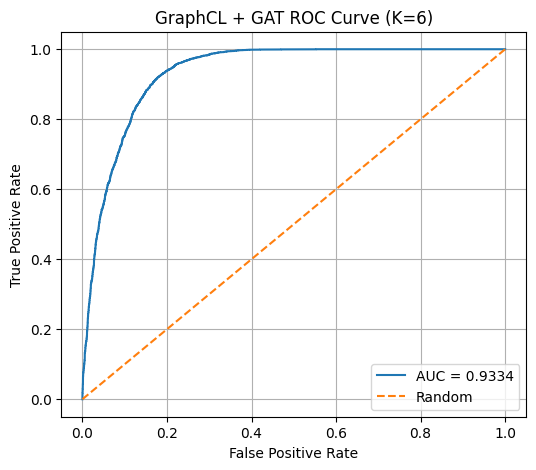

ROC-AUC: 0.9333568701427546


In [143]:
positive_scores = test_probs[:, 1]
fpr, tpr, _ = roc_curve(test_labels, positive_scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"GraphCL + GAT ROC Curve (K={K})")
plt.legend()
plt.grid(True)
plt.show()

print("ROC-AUC:", roc_auc)

## 12. Learning Curves

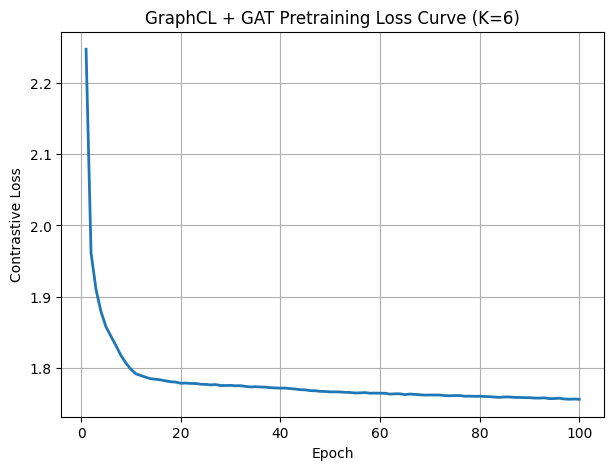

In [144]:
plt.figure(figsize=(7, 5))
plt.plot(graphcl_history["epoch"], graphcl_history["loss"], linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Contrastive Loss")
plt.title(f"GraphCL + GAT Pretraining Loss Curve (K={K})")
plt.grid(True)
plt.show()

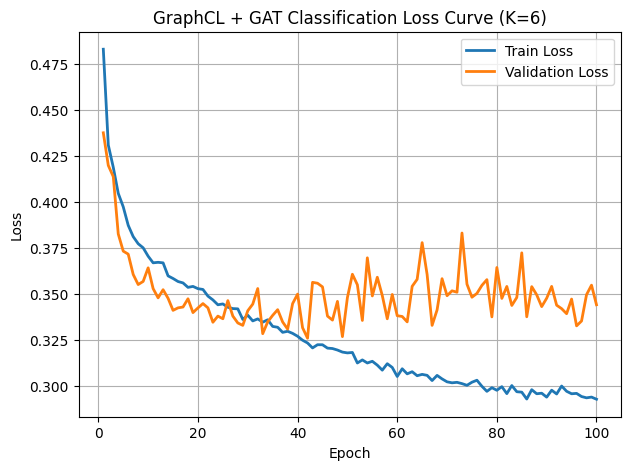

In [145]:
plt.figure(figsize=(7, 5))
plt.plot(history["epoch"], history["train_loss"], label="Train Loss", linewidth=2)
plt.plot(history["epoch"], history["val_loss"], label="Validation Loss", linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"GraphCL + GAT Classification Loss Curve (K={K})")
plt.legend()
plt.grid(True)
plt.show()

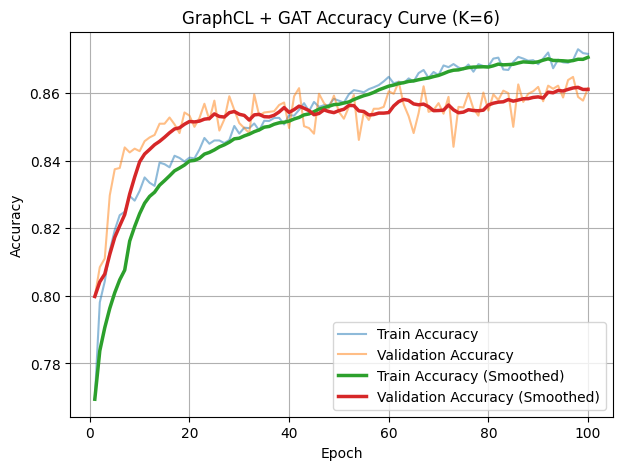

In [146]:
plt.figure(figsize=(7, 5))
plt.plot(history["epoch"], history["train_acc"], label="Train Accuracy", linewidth=1.5, alpha=0.5)
plt.plot(history["epoch"], history["val_acc"], label="Validation Accuracy", linewidth=1.5, alpha=0.5)

train_smooth = pd.Series(history["train_acc"]).rolling(window=7, min_periods=1).mean()
val_smooth = pd.Series(history["val_acc"]).rolling(window=7, min_periods=1).mean()

plt.plot(history["epoch"], train_smooth, label="Train Accuracy (Smoothed)", linewidth=2.5)
plt.plot(history["epoch"], val_smooth, label="Validation Accuracy (Smoothed)", linewidth=2.5)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title(f"GraphCL + GAT Accuracy Curve (K={K})")
plt.legend()
plt.grid(True)
plt.show()

## 13. Save Model and Results

In [147]:
results = {
    "K": K,
    "test_loss": float(test_loss),
    "test_acc": float(test_acc),
    "roc_auc": float(roc_auc),
    "classification_report": classification_report(test_labels, test_preds, digits=4, output_dict=True),
    "history": history,
    "graphcl_history": graphcl_history,
}

torch.save(model.state_dict(), f"gat_classifier_k{K}.pt")
torch.save({
    "K": K,
    "IN_DIM": IN_DIM,
    "encoder_state_dict": gat_encoder.state_dict(),
    "model_state_dict": model.state_dict(),
    "config": {
        "hidden_dim": HIDDEN_DIM,
        "heads": HEADS,
        "dropout_encoder": DROPOUT_ENCODER,
        "dropout_classifier": DROPOUT_CLASSIFIER,
        "pretrain_epochs": PRETRAIN_EPOCHS,
        "classifier_epochs": CLASSIFIER_EPOCHS,
        "ssl_lr": SSL_LR,
        "cls_lr": CLS_LR,
        "weight_decay": WEIGHT_DECAY,
    },
    "results": results
}, f"graphcl_gat_checkpoint_k{K}.pt")

torch.save(results, f"graphcl_gat_results_k{K}.pt")

print("Saved files:")
print(f"gat_classifier_k{K}.pt")
print(f"graphcl_gat_checkpoint_k{K}.pt")
print(f"graphcl_gat_results_k{K}.pt")

Saved files:
gat_classifier_k6.pt
graphcl_gat_checkpoint_k6.pt
graphcl_gat_results_k6.pt


## 14. How to Compare K=5, K=6, K=7

Run this notebook three times by changing `K` in the configuration cell:

1. `K = 5`
2. `K = 6`
3. `K = 7`

After all runs, use the saved result files to compare Accuracy and ROC-AUC.

In [148]:
# Run this only after you have completed K=5, K=6, and K=7 experiments.
summary_rows = []

for k_value in [5, 6, 7]:
    path = f"graphcl_gat_results_k{k_value}.pt"
    if os.path.exists(path):
        r = torch.load(path, weights_only=False)
        summary_rows.append({
            "K": k_value,
            "Test Accuracy": r["test_acc"],
            "ROC-AUC": r["roc_auc"],
            "Test Loss": r["test_loss"]
        })

if summary_rows:
    summary_df = pd.DataFrame(summary_rows)
    display(summary_df)
else:
    print("No saved K-result files found yet. Run the notebook for K=5, K=6, and K=7 first.")

,K,Test Accuracy,ROC-AUC,Test Loss
0,5,0.842263,0.915879,0.352345
1,6,0.855103,0.933357,0.346367
2,7,0.844366,0.918284,0.347690


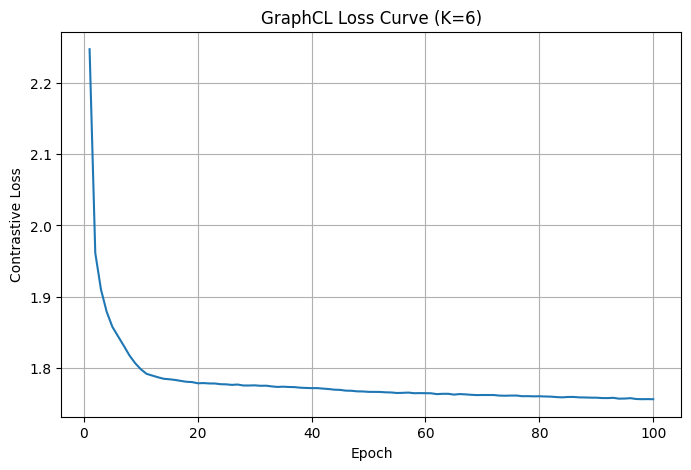

In [149]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(graphcl_history["epoch"], graphcl_history["loss"])

plt.xlabel("Epoch")
plt.ylabel("Contrastive Loss")
plt.title(f"GraphCL Loss Curve (K={K})")
plt.grid(True)

plt.savefig(f"graphcl_loss_k{K}.png", dpi=300, bbox_inches='tight')
plt.show()

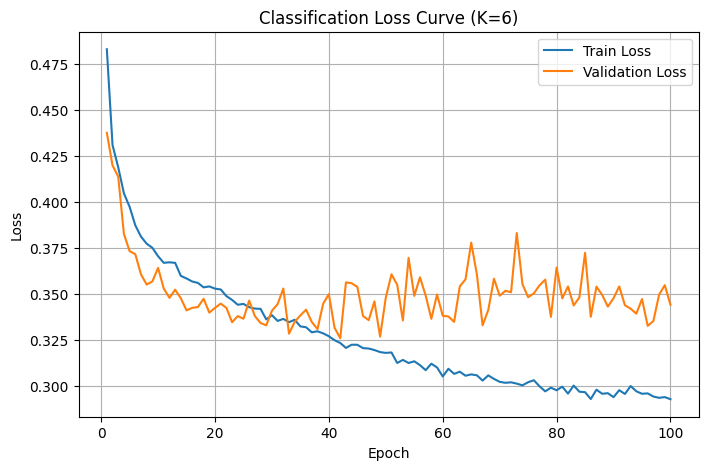

In [150]:
plt.figure(figsize=(8,5))
plt.plot(history["epoch"], history["train_loss"], label="Train Loss")
plt.plot(history["epoch"], history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"Classification Loss Curve (K={K})")
plt.legend()
plt.grid(True)

plt.savefig(f"classification_loss_k{K}.png", dpi=300, bbox_inches='tight')
plt.show()

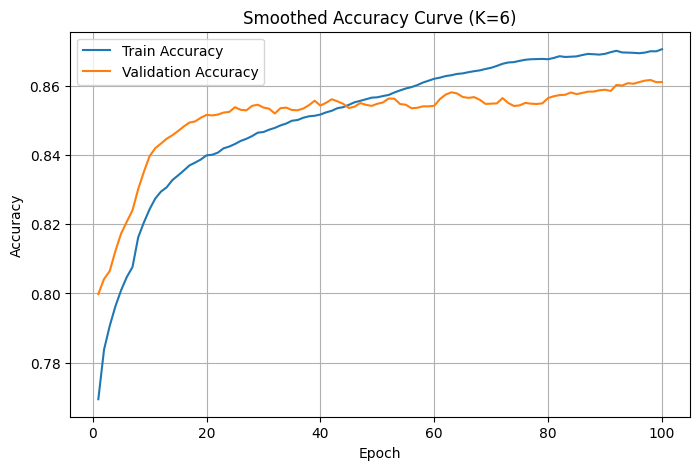

In [151]:
import pandas as pd

train_smooth = pd.Series(history["train_acc"]).rolling(window=7, min_periods=1).mean()
val_smooth = pd.Series(history["val_acc"]).rolling(window=7, min_periods=1).mean()

plt.figure(figsize=(8,5))
plt.plot(history["epoch"], train_smooth, label="Train Accuracy")
plt.plot(history["epoch"], val_smooth, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title(f"Smoothed Accuracy Curve (K={K})")
plt.legend()
plt.grid(True)

plt.savefig(f"accuracy_curve_k{K}.png", dpi=300, bbox_inches='tight')
plt.show()

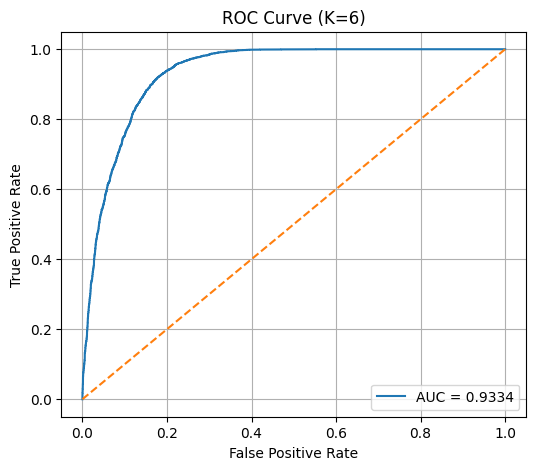

In [152]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(test_labels, test_probs[:,1])
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve (K={K})")
plt.legend()
plt.grid(True)

plt.savefig(f"roc_curve_k{K}.png", dpi=300, bbox_inches='tight')
plt.show()